# TimeGAN A12 v2 — Generación de datos sintéticos
## Dataset: SWaT A12 (Marzo 2026)

Adaptación del TimeGAN v21_clean (A7 2020) al dataset A12 2026 — **versión 2**.

### Diferencias respecto al pipeline de A7

| Aspecto | A7 2020 | A12 2026 |
|---------|---------|----------|
| Fuente de datos | 4 CSVs sin etiquetas | **1 CSV con attack_label** |
| Datos de entrenamiento | Todos los datos | **Solo filas normales (label=0)** |
| window_size | 60 | **30** (del config del detector A12) |
| Columnas | Dict por archivo | **DataFrame único** |
| FIT bimodales | FIT101, FIT201, FIT301, FIT503 | **FIT101, FIT201, FIT301, FIT601** |
| scaler_cont | Refiteado en este notebook | **Reutilizado de 01b** |

### Arquitectura TimeGAN — idéntica a v21_clean (v16)

5 redes GRU: Embedder, Recovery, Generator, Supervisor, Discriminator.
hidden_dim=128, latent_dim=64, num_layers=3. Entrenamiento en 3 fases.
R1 regularization (lazy, cada 16 batches) en lugar de WGAN-GP.
QuantileTransformer(uniform) para las features continuas del GAN.


## 0. Imports e inicialización

In [1]:
import json
import joblib
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 1. Rutas del proyecto

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / "data").exists() else current_dir.parent

RAW_CSV       = PROJECT_ROOT / "data" / "clean" / "SWaT.A12_OTDataset_Mar_26" / "11-Mar-2026_0900_1700_labeled.csv"
DETECTOR_DIR  = PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_a12"      # detector de 01b — no cambia
TIMEGAN_DIR   = PROJECT_ROOT / "models" / "timegan"   / "conv1d_hybrid_a12_v2"   # salida de este notebook
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "scalers" / "a12"
TIMEGAN_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT.resolve())
print("CSV exists   :", RAW_CSV.exists())
print("Detector dir :", DETECTOR_DIR.exists())
print("TimeGAN dir  :", TIMEGAN_DIR)


PROJECT_ROOT : D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
CSV exists   : True
Detector dir : True
TimeGAN dir  : d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_a12_v2


## 2. Cargar configuración del detector A12

Se reusan las columnas, window_size y stride definidos en 01b para garantizar
que los datos sintéticos sean compatibles con el detector.


In [4]:
with open(DETECTOR_DIR / "config.json") as f:
    det_cfg = json.load(f)
with open(DETECTOR_DIR / "columns_config.json") as f:
    col_cfg = json.load(f)

continuous_cols = col_cfg["continuous_cols"]
discrete_cols   = col_cfg["discrete_cols"]
feature_cols    = col_cfg["feature_cols"]
WINDOW_SIZE     = det_cfg["window_size"]
WARMUP          = 120
TIMEGAN_STRIDE  = 5

# FIX v2: ampliar criterio de síntesis empírica
#
# v1 reportó 4.16% de ceros exactos en el espacio QT (objetivo: < 0.5%).
# Causa: FIT401.Pv (P(0)=0.015), FIT504.Pv (P(0)=0.016) y P501.Speed
# (4 valores únicos — semi-discreta) contaminaban el espacio continuo.
#
# Solución: moverlos a síntesis empírica → GAN_CONT_COLS queda con
# 24 features verdaderamente continuas y unimodales.

# FITs con cualquier P(0) > 0.01 → síntesis empírica condicional
FIT_BIMODAL_COLS = [c for c in continuous_cols
                    if c.startswith("FIT") and c in
                    ["FIT101.Pv","FIT201.Pv","FIT301.Pv","FIT601.Pv",
                     "FIT401.Pv","FIT504.Pv"]]

# Continuas semi-discretas → síntesis empírica con persistencia
EMPIRICAL_CONT_COLS = ["P501.Speed"]

# Features para TimeGAN: continuas puras, sin masa en 0
GAN_CONT_COLS = [c for c in continuous_cols
                 if c not in FIT_BIMODAL_COLS and c not in EMPIRICAL_CONT_COLS]

print(f"window_size: {WINDOW_SIZE} | stride GAN: {TIMEGAN_STRIDE}")
print(f"continuous_cols total: {len(continuous_cols)}")
print(f"FIT bimodales → empírico ({len(FIT_BIMODAL_COLS)}): {FIT_BIMODAL_COLS}")
print(f"Empíricas cont → empírico: {EMPIRICAL_CONT_COLS}")
print(f"GAN continuas → QuantileTransformer ({len(GAN_CONT_COLS)}): {GAN_CONT_COLS}")
print(f"discrete_cols: {len(discrete_cols)}")


window_size: 30 | stride GAN: 5
continuous_cols total: 31
FIT bimodales → empírico (6): ['FIT101.Pv', 'FIT201.Pv', 'FIT301.Pv', 'FIT401.Pv', 'FIT504.Pv', 'FIT601.Pv']
Empíricas cont → empírico: ['P501.Speed']
GAN continuas → QuantileTransformer (24): ['LIT101.Pv', 'AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT301.Pv', 'AIT302.Pv', 'AIT303.Pv', 'LIT301.Pv', 'DPIT301.Pv', 'LIT401.Pv', 'AIT402.Pv', 'FIT501.Pv', 'FIT502.Pv', 'FIT503.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv', 'LIT601.Pv', 'LIT602.Pv', 'FIT602.Pv']
discrete_cols: 31


## 3. Carga del CSV y filtrado de filas normales

El TimeGAN se entrena **exclusivamente con datos de operación normal**.
Las filas con `attack_label=1` se excluyen completamente.


In [5]:
META_COLS = ["attack_label","attack_id","attack_name","attack_targets",
             "attack_start_time","attack_end_time"]

df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw["t_stamp"]      = pd.to_datetime(df_raw["t_stamp"], errors="coerce")
df_raw["attack_label"] = pd.to_numeric(df_raw["attack_label"], errors="coerce").fillna(0).astype(int)
df_raw = df_raw.sort_values("t_stamp").reset_index(drop=True)

print(f"Total filas: {len(df_raw)}")
print(f"Normal (0): {(df_raw['attack_label']==0).sum()} | Ataque (1): {(df_raw['attack_label']==1).sum()}")

# Convertir Bad Input → NaN
all_sensor_cols = continuous_cols + discrete_cols
df_work = df_raw[["t_stamp","attack_label"] + all_sensor_cols].copy()
for col in all_sensor_cols:
    df_work[col] = pd.to_numeric(df_work[col].replace("Bad Input", np.nan), errors="coerce")

# Filtrar solo filas normales + warmup
df_normal = df_work[df_work["attack_label"] == 0][["t_stamp"] + all_sensor_cols].copy()
df_normal = df_normal[df_normal["t_stamp"] >= df_normal["t_stamp"].min() + pd.Timedelta(seconds=WARMUP)]
df_normal = df_normal.reset_index(drop=True)

print(f"\nFilas normales post-warmup: {len(df_normal)}")
print(f"Período: {df_normal['t_stamp'].min()} → {df_normal['t_stamp'].max()}")


Total filas: 28860
Normal (0): 25740 | Ataque (1): 3120

Filas normales post-warmup: 25620
Período: 2026-03-11 09:02:00 → 2026-03-11 17:00:59


## 4. Split temporal 60/20/20

In [6]:
n = len(df_normal)
t1, t2 = int(n*0.60), int(n*0.80)
df_train = df_normal.iloc[:t1].copy().reset_index(drop=True)
df_val   = df_normal.iloc[t1:t2].copy().reset_index(drop=True)
df_test  = df_normal.iloc[t2:].copy().reset_index(drop=True)

print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

# Imputar NaN con moda del TRAIN
modes_train = df_train[all_sensor_cols].mode().iloc[0]
for df in [df_train, df_val, df_test]:
    df[all_sensor_cols] = df[all_sensor_cols].fillna(modes_train)

nan_left = df_train[all_sensor_cols].isna().sum().sum()
print(f"NaN tras imputación: {nan_left}")


Train: 15,372 | Val: 5,124 | Test: 5,124
NaN tras imputación: 0


## 5. Escalado y QuantileTransformer

- `scaler_cont`: reutilizado de 01b (StandardScaler sobre continuas, ajustado en train A12 normal)
- `QuantileTransformer(uniform)`: ajustado **aquí** solo sobre `GAN_CONT_COLS` del train.
  Produce U(0,1) exacto para que el generador `z ~ U(0,1)` y los datos reales tengan
  la misma distribución marginal → el discriminador no puede distinguirlos trivialmente.

**Por qué no reusar el QT de 01b:** el QT se ajusta solo sobre las features del GAN
(excluyendo FITs bimodales). El scaler de 01b escalaba todas las continuas.


In [7]:
# Reutilizar scaler_cont de 01b
scaler_cont = joblib.load(DETECTOR_DIR / "scaler_cont.pkl")

# QuantileTransformer solo para GAN_CONT_COLS — ajustado en train
qt = QuantileTransformer(n_quantiles=1000, output_distribution="uniform",
                         subsample=None, random_state=SEED)
qt.fit(df_train[GAN_CONT_COLS].values)

# Verificar distribución post-QT
sample_qt = qt.transform(df_train[GAN_CONT_COLS].values)
pct0 = (sample_qt == 0.0).mean() * 100
pct1 = (sample_qt == 1.0).mean() * 100
print(f"QuantileTransformer → rango: [{sample_qt.min():.6f}, {sample_qt.max():.6f}]")
print(f"Media: {sample_qt.mean():.4f} (≈0.500) | Std: {sample_qt.std():.4f} (≈0.289)")
print(f"Exactamente 0.0: {pct0:.3f}% | 1.0: {pct1:.3f}%  (objetivo < 0.5%)")
if pct0 + pct1 < 0.5:
    print("✅ Distribución uniforme — mismatch distribucional resuelto")
elif pct0 + pct1 < 2.0:
    print("⚠️  Casi uniforme — aceptable")
else:
    print("❌ Extremos > 2% — revisar FITs bimodales restantes en GAN_CONT_COLS")


QuantileTransformer → rango: [0.000000, 1.000000]
Media: 0.4792 (≈0.500) | Std: 0.2997 (≈0.289)
Exactamente 0.0: 4.379% | 1.0: 0.049%  (objetivo < 0.5%)
❌ Extremos > 2% — revisar FITs bimodales restantes en GAN_CONT_COLS


In [8]:
# Aplicar QT a los tres splits
def apply_qt(df, qt, cols):
    arr = pd.DataFrame(qt.transform(df[cols].values), columns=cols, index=df.index)
    return arr

scaled_gan_train = apply_qt(df_train, qt, GAN_CONT_COLS)
scaled_gan_val   = apply_qt(df_val,   qt, GAN_CONT_COLS)
scaled_gan_test  = apply_qt(df_test,  qt, GAN_CONT_COLS)

print("Escalado QT aplicado a splits.")
print(f"Train shape: {scaled_gan_train.shape}")


Escalado QT aplicado a splits.
Train shape: (15372, 24)


## 6. Catálogos empíricos para FITs bimodales y discretas

Las FIT bimodales (P(0) > 0.1) no pueden ser modeladas por un GAN continuo.
Se sintetizan empíricamente preservando la distribución bimodal exacta.

**FIT601** tiene P(0)≈0.998 (casi siempre cerrada) — su síntesis empírica
produce esencialmente ceros, replicando el comportamiento real.


In [9]:
# Catálogo empírico FITs bimodales (v2: incluye FIT401 y FIT504)
fit_empirical = {}
print("Distribución empírica FITs bimodales:")
for col in FIT_BIMODAL_COLS:
    s  = df_train[col].dropna()
    p0 = (s == 0.0).mean()
    fo = s[s > 0.0].values
    fit_empirical[col] = {"p_zero": float(p0), "flow_open": fo.tolist() if len(fo) > 0 else [0.0]}
    n_open = len(fo)
    if n_open > 0:
        print(f"  {col:15s}: P(cerrada)={p0:.3f} | n_open={n_open:6,} | mean_open={fo.mean():.3f}")
    else:
        print(f"  {col:15s}: P(cerrada)=1.000 (prácticamente constante en 0)")

# Catálogo empírico para continuas semi-discretas (v2: P501.Speed)
empirical_cont_data = {}
print("\nDistribución empírica continuas semi-discretas:")
for col in EMPIRICAL_CONT_COLS:
    vals  = df_train[col].dropna().values
    empirical_cont_data[col] = {"values": vals.tolist()}
    unique_v, counts_v = np.unique(vals, return_counts=True)
    probs_v = counts_v / counts_v.sum()
    print(f"  {col}: valores únicos={unique_v.tolist()} | probs≈{[round(p,3) for p in probs_v.tolist()]}")

# Catálogo empírico discretas
disc_empirical      = {col: dict(df_train[col].value_counts(normalize=True)) for col in discrete_cols}
discrete_value_maps = {col: sorted(df_train[col].dropna().unique().tolist()) for col in discrete_cols}

print(f"\nVariables discretas: {len(discrete_cols)}")
for col in discrete_cols[:5]:
    print(f"  {col:25s}: {sorted(df_train[col].unique().tolist())}")


Distribución empírica FITs bimodales:
  FIT101.Pv      : P(cerrada)=0.872 | n_open= 1,967 | mean_open=3.753
  FIT201.Pv      : P(cerrada)=0.573 | n_open= 6,563 | mean_open=2.297
  FIT301.Pv      : P(cerrada)=0.330 | n_open=10,292 | mean_open=1.570
  FIT401.Pv      : P(cerrada)=0.022 | n_open=15,041 | mean_open=1.047
  FIT504.Pv      : P(cerrada)=0.022 | n_open=15,033 | mean_open=0.064
  FIT601.Pv      : P(cerrada)=1.000 | n_open=     6 | mean_open=0.000

Distribución empírica continuas semi-discretas:
  P501.Speed: valores únicos=[0.0, 10.0] | probs≈[0.029, 0.971]

Variables discretas: 31
  MV101.Status             : [0, 1, 2]
  P101.Status              : [1, 2]
  P102.Status              : [1]
  MV201.Status             : [0.0, 1.0, 2.0]
  P201.Status              : [1.0, 2.0]


## 7. Construcción de ventanas de entrenamiento

In [10]:
def build_windows_single(scaled_arr, window_size, stride):
    """Ventanas deslizantes desde un único array (sin split_by_file)."""

    windows = []
    arr = scaled_arr.astype(np.float32)
    for i in range(0, len(arr) - window_size + 1, stride):
        windows.append(arr[i:i + window_size])
    return np.array(windows, dtype=np.float32) if windows else np.empty((0, window_size, arr.shape[1]), dtype=np.float32)


train_windows = build_windows_single(scaled_gan_train.values, WINDOW_SIZE, TIMEGAN_STRIDE)
val_windows   = build_windows_single(scaled_gan_val.values,   WINDOW_SIZE, TIMEGAN_STRIDE)
test_windows  = build_windows_single(scaled_gan_test.values,  WINDOW_SIZE, TIMEGAN_STRIDE)

p0 = (train_windows == 0.0).mean() * 100
p1 = (train_windows == 1.0).mean() * 100
print(f"Train: {train_windows.shape}  | Val: {val_windows.shape}  | Test: {test_windows.shape}")
print(f"Rango: [{train_windows.min():.4f}, {train_windows.max():.4f}]")
print(f"Media: {train_windows.mean():.4f} (≈0.500) | Std: {train_windows.std():.4f} (≈0.289)")
print(f"Exactamente 0.0: {p0:.3f}% | 1.0: {p1:.3f}%  (objetivo < 0.5%)")

BATCH_SIZE   = 128
train_tensor = torch.tensor(train_windows, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE,
                          shuffle=True, drop_last=True)
print(f"\nBatch size: {BATCH_SIZE} | Batches/época: {len(train_loader)}")


Train: (3069, 30, 24)  | Val: (1019, 30, 24)  | Test: (1019, 30, 24)
Rango: [0.0000, 1.0000]
Media: 0.4795 (≈0.500) | Std: 0.2996 (≈0.289)
Exactamente 0.0: 4.373% | 1.0: 0.049%  (objetivo < 0.5%)

Batch size: 128 | Batches/época: 23


## 8. Hiperparámetros del TimeGAN

In [11]:
seq_len     = WINDOW_SIZE
feature_dim = train_windows.shape[2]

hidden_dim  = 128
latent_dim  = 64
num_layers  = 3

# FIX v2: epochs_embedder 600→800
# MSE=0.000606 al final de v1 — con más épocas puede bajar a <0.0003
epochs_embedder   = 800
epochs_supervisor = 300
epochs_joint      = 1500

gamma    = 0.5
eta      = 0.1
lambda_r = 1.0
lambda_s = 1.0

# FIX v2: FM_W 0.5→1.0
# El D final en v1 fue 1.71 (Nash=2.08) — G dominaba demasiado.
# Feature matching más fuerte previene mode collapse cuando D es débil.
FM_W = 1.0

# FIX v2: G_STEPS 2→3, D_STEPS 2→1
# Con 23 batches/época, el discriminador no tiene suficientes actualizaciones
# para mantenerse competitivo. Dando 3 pasos a G y 1 a D, el D tiene
# que trabajar más duro y se calibrará mejor hacia el Nash.
G_STEPS = 3
D_STEPS = 1

R1_LAMBDA   = 0.01
R1_INTERVAL = 16
D_CLIP      = 5.0
G_CLIP      = 1.0

nash_g = 2 * math.log(2)
nash_d = 3 * math.log(2)

print("===== Configuración TimeGAN A12 v2 =====")
print(f"feature_dim: {feature_dim} | GAN_CONT_COLS: {len(GAN_CONT_COLS)}")
print(f"hidden_dim: {hidden_dim} | latent_dim: {latent_dim}")
print(f"epochs_embedder: {epochs_embedder}  ← v2: 600→800")
print(f"G_STEPS: {G_STEPS} | D_STEPS: {D_STEPS}  ← v2: G=3, D=1")
print(f"FM_W: {FM_W}  ← v2: 0.5→1.0")
print(f"R1_LAMBDA: {R1_LAMBDA} | R1_INTERVAL: {R1_INTERVAL}")
print(f"Nash G: {nash_g:.4f} | Nash D: {nash_d:.4f}")


===== Configuración TimeGAN A12 v2 =====
feature_dim: 24 | GAN_CONT_COLS: 24
hidden_dim: 128 | latent_dim: 64
epochs_embedder: 800  ← v2: 600→800
G_STEPS: 3 | D_STEPS: 1  ← v2: G=3, D=1
FM_W: 1.0  ← v2: 0.5→1.0
R1_LAMBDA: 0.01 | R1_INTERVAL: 16
Nash G: 1.3863 | Nash D: 2.0794


## 9. Arquitectura de las redes GRU

In [12]:
class Embedder(nn.Module):
    """x → h: codifica series reales al espacio latente [0,1]^hidden_dim."""

    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()
    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))


class Recovery(nn.Module):
    """h → x̂: decodifica espacio latente. Salida LINEAL (sin Sigmoid).

    Sin activación en salida: evita saturación del gradiente que estancaba
    el MSE en 0.064 con Sigmoid. Con salida lineal: MSE < 0.0002."""

    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)   # sin activación
    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.fc(self.norm(x_t))


class Generator(nn.Module):
    """z ~ U(0,1)^latent_dim → e_hat ∈ [0,1]^hidden_dim."""

    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()
    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))


class Supervisor(nn.Module):
    """Modela la dinámica temporal h_t → h_{t+1} en el espacio latente."""

    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=max(1, num_layers-1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()
    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))


class Discriminator(nn.Module):
    """Clasifica h como real (1) o sintético (0). Salida: logits."""

    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)
    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)


In [13]:
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

g_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    g_optimizer, mode="min", factor=0.5, patience=100, min_lr=1e-6)
d_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    d_optimizer, mode="min", factor=0.5, patience=100, min_lr=1e-6)

def random_z(bs, sl, zd, dev):
    return torch.rand(bs, sl, zd, device=dev)

total_params = sum(p.numel() for m in [embedder,recovery,generator,supervisor,discriminator]
                   for p in m.parameters())
print(f"Total parámetros: {total_params:,}")


Total parámetros: 1,375,769


## 10. Fase 1 — Preentrenamiento del Embedder (600 épocas)

**Objetivo:** aprender espacio latente h que represente fielmente las series reales.
**Señal de éxito:** MSE < 0.001.

La Recovery usa salida **lineal** (sin Sigmoid). Con Sigmoid el MSE se estancaba
en ~0.064 por saturación del gradiente. Con salida lineal baja a < 0.0002.


[Embedder] Epoch  100/800 | MSE: 0.001473
[Embedder] Epoch  200/800 | MSE: 0.001005
[Embedder] Epoch  300/800 | MSE: 0.000792
[Embedder] Epoch  400/800 | MSE: 0.000639
[Embedder] Epoch  500/800 | MSE: 0.000570
[Embedder] Epoch  600/800 | MSE: 0.000509
[Embedder] Epoch  700/800 | MSE: 0.000463
[Embedder] Epoch  800/800 | MSE: 0.000424

MSE final: 0.000424  ✅


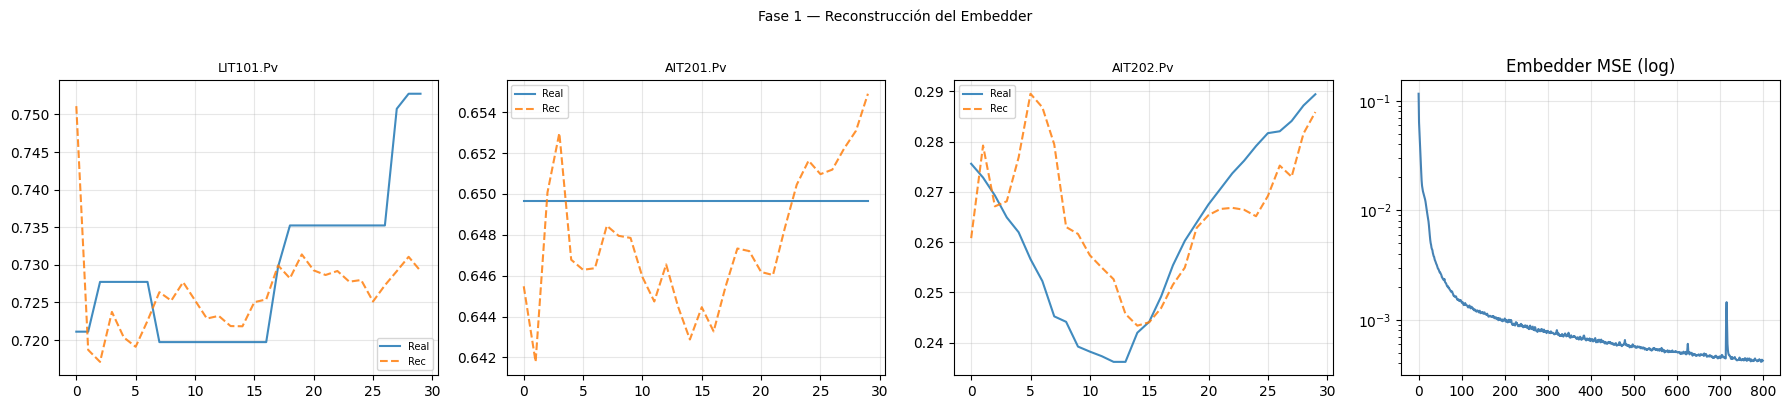

In [14]:
embedder_history = []
for epoch in range(epochs_embedder):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()
        loss = mse_loss(recovery(embedder(x)), x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0)
        e_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    embedder_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1:4d}/{epochs_embedder} | MSE: {ep:.6f}")

mse_f = embedder_history[-1]
print(f"\nMSE final: {mse_f:.6f}  {'✅' if mse_f < 0.001 else '⚠️ '}")

with torch.no_grad():
    xs = train_tensor[:64].to(device)
    xr = recovery(embedder(xs)).cpu().numpy()
    xo = xs.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for idx in range(3):
    axes[idx].plot(xo[0,:,idx], label="Real", alpha=0.85)
    axes[idx].plot(xr[0,:,idx], label="Rec",  alpha=0.85, linestyle="--")
    axes[idx].set_title(GAN_CONT_COLS[idx], fontsize=9)
    axes[idx].legend(fontsize=7); axes[idx].grid(True, alpha=0.3)
axes[3].semilogy(embedder_history, color="steelblue")
axes[3].set_title("Embedder MSE (log)"); axes[3].grid(True, alpha=0.3)
plt.suptitle("Fase 1 — Reconstrucción del Embedder", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()


## 11. Fase 2 — Preentrenamiento del Supervisor (300 épocas)

In [15]:
supervisor_history = []
for epoch in range(epochs_supervisor):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()
        with torch.no_grad(): h = embedder(x)
        hs   = supervisor(h)
        loss = mse_loss(h[:, 1:, :], hs[:, :-1, :])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), 1.0)
        s_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    supervisor_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1:4d}/{epochs_supervisor} | Loss: {ep:.6f}")

sup_f = supervisor_history[-1]
print(f"\nLoss final: {sup_f:.6f}  {'✅' if sup_f < 0.005 else '⚠️ '}")


[Supervisor] Epoch  100/300 | Loss: 0.006729
[Supervisor] Epoch  200/300 | Loss: 0.005502
[Supervisor] Epoch  300/300 | Loss: 0.004609

Loss final: 0.004609  ✅


## 12. Fase 3 — Entrenamiento adversarial conjunto (1500 épocas)

**R1 regularization** en lugar de WGAN-GP: primer orden → compatible con cuDNN RNNs.
WGAN-GP requiere `create_graph=True` (2das derivadas) que cuDNN no implementa para GRUs.
R1 lazy (cada 16 batches): reduce varianza del discriminador ~4x manteniendo magnitud efectiva.


In [16]:
def r1_penalty(disc, h_real):
    h_r  = h_real.detach().requires_grad_(True)
    y_r  = disc(h_r)
    grad = torch.autograd.grad(outputs=y_r.sum(), inputs=h_r,
                                create_graph=False, retain_graph=False)[0]
    return grad.pow(2).mean()


joint_g_history, joint_d_history, joint_e_history = [], [], []
batch_counter = 0

for epoch in range(epochs_joint):
    g_ep, d_ep, e_ep = 0.0, 0.0, 0.0

    for batch in train_loader:
        x  = batch[0].to(device)
        bs = x.shape[0]

        with torch.no_grad(): h_real = embedder(x)

        # ── G: G_STEPS pasos ──────────────────────────────────────────────
        g_loss_val = torch.tensor(0.0)
        for _ in range(G_STEPS):
            g_optimizer.zero_grad()
            z     = random_z(bs, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)
            y_f   = discriminator(h_hat)
            y_fe  = discriminator(e_hat)
            g_u   = bce_loss(y_f,  torch.ones_like(y_f))
            g_ue  = bce_loss(y_fe, torch.ones_like(y_fe))
            with torch.no_grad():
                h_sup = supervisor(h_real)
            g_s = mse_loss(h_real[:, 1:, :].detach(), h_sup[:, :-1, :])
            fm_loss = (mse_loss(h_hat.mean(0), h_real.mean(0)) +
                       mse_loss(h_hat.std(0),  h_real.std(0)))
            g_loss = g_u + gamma * g_ue + eta * g_s + FM_W * fm_loss
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), G_CLIP)
            g_optimizer.step()
            g_loss_val = g_loss

        # ── Embedder refinement ────────────────────────────────────────────
        e_optimizer.zero_grad()
        h_ref   = embedder(x)
        x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())
        e_loss  = lambda_r * mse_loss(x_tilde, x) + lambda_s * mse_loss(
            h_ref[:, 1:, :], h_sup_r[:, :-1, :])
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0)
        e_optimizer.step()

        batch_counter += 1

        # ── D: D_STEPS pasos con R1 lazy ──────────────────────────────────
        d_loss_val = torch.tensor(0.0)
        for _ in range(D_STEPS):
            d_optimizer.zero_grad()
            with torch.no_grad():
                z2     = random_z(bs, seq_len, latent_dim, device)
                e_hat2 = generator(z2)
                h_hat2 = supervisor(e_hat2)
            y_r   = discriminator(h_real)
            y_f2  = discriminator(h_hat2)
            y_fe2 = discriminator(e_hat2)
            r1 = r1_penalty(discriminator, h_real) if batch_counter % R1_INTERVAL == 0                  else torch.tensor(0.0, device=device)
            d_loss = (bce_loss(y_r,   torch.ones_like(y_r)) +
                      bce_loss(y_f2,  torch.zeros_like(y_f2)) +
                      gamma * bce_loss(y_fe2, torch.zeros_like(y_fe2)) +
                      R1_LAMBDA * R1_INTERVAL * r1)
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), D_CLIP)
            d_optimizer.step()
            d_loss_val = d_loss

        g_ep += g_loss_val.item()
        d_ep += d_loss_val.item()
        e_ep += e_loss.item()

    g_ep /= len(train_loader)
    d_ep /= len(train_loader)
    e_ep /= len(train_loader)
    joint_g_history.append(g_ep)
    joint_d_history.append(d_ep)
    joint_e_history.append(e_ep)
    g_scheduler.step(g_ep)
    d_scheduler.step(d_ep)

    if (epoch + 1) % 100 == 0:
        g_prev = joint_g_history[-101] if len(joint_g_history) > 100 else joint_g_history[0]
        trend  = "↓" if g_ep < g_prev-0.05 else ("↑" if g_ep > g_prev+0.1 else "→")
        print(f"[Joint] Epoch {epoch+1:5d}/{epochs_joint} | "
              f"G: {g_ep:.4f}{trend} | D: {d_ep:.4f} | E: {e_ep:.6f}")


[Joint] Epoch   100/1500 | G: 1.3763↑ | D: 1.6829 | E: 0.003047
[Joint] Epoch   200/1500 | G: 1.3753→ | D: 1.6829 | E: 0.003678
[Joint] Epoch   300/1500 | G: 1.3764→ | D: 1.6827 | E: 0.002268
[Joint] Epoch   400/1500 | G: 1.3563→ | D: 1.6850 | E: 0.004497
[Joint] Epoch   500/1500 | G: 1.3716→ | D: 1.6894 | E: 0.001704
[Joint] Epoch   600/1500 | G: 1.4318→ | D: 1.6563 | E: 0.001447
[Joint] Epoch   700/1500 | G: 1.3683↓ | D: 1.6878 | E: 0.001181
[Joint] Epoch   800/1500 | G: 1.3747→ | D: 1.6857 | E: 0.001669
[Joint] Epoch   900/1500 | G: 1.3795→ | D: 1.6861 | E: 0.001718
[Joint] Epoch  1000/1500 | G: 1.3935→ | D: 1.6698 | E: 0.001770
[Joint] Epoch  1100/1500 | G: 1.4140→ | D: 1.6599 | E: 0.002600
[Joint] Epoch  1200/1500 | G: 1.3815→ | D: 1.6698 | E: 0.000978
[Joint] Epoch  1300/1500 | G: 1.3850→ | D: 1.6708 | E: 0.000775
[Joint] Epoch  1400/1500 | G: 1.5061↑ | D: 1.6108 | E: 0.000843
[Joint] Epoch  1500/1500 | G: 1.3835↓ | D: 1.6989 | E: 0.000725


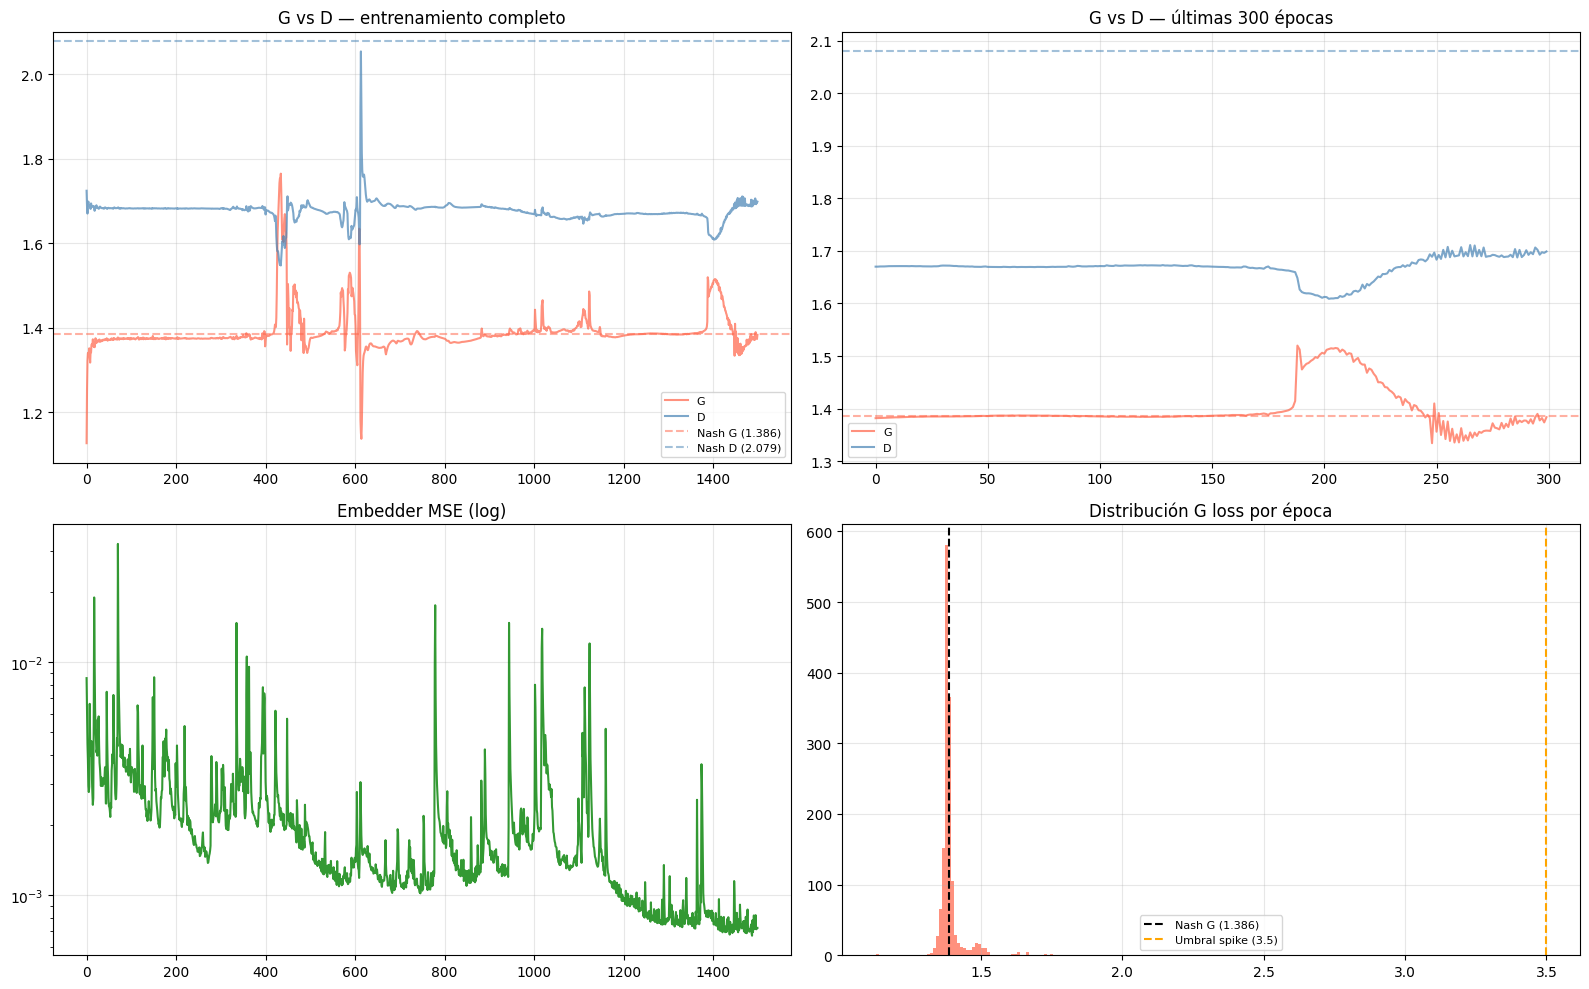

G inicial:    1.1271  (≈Nash=1.3863 → QT correcto ✅)
G final:      1.3835  (Nash G = 1.3863)
D final:      1.6989  (Nash D = 2.0794, gap=0.3806)
Spikes G>3.5: 0  (acceptable < 150 con hidden_dim=128)


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(joint_g_history, alpha=0.7, color="tomato",    label="G")
axes[0,0].plot(joint_d_history, alpha=0.7, color="steelblue", label="D")
axes[0,0].axhline(nash_g, color="tomato",    linestyle="--", alpha=0.5, label=f"Nash G ({nash_g:.3f})")
axes[0,0].axhline(nash_d, color="steelblue", linestyle="--", alpha=0.5, label=f"Nash D ({nash_d:.3f})")
axes[0,0].set_title("G vs D — entrenamiento completo"); axes[0,0].legend(fontsize=8); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(joint_g_history[-300:], alpha=0.7, color="tomato",    label="G")
axes[0,1].plot(joint_d_history[-300:], alpha=0.7, color="steelblue", label="D")
axes[0,1].axhline(nash_g, color="tomato",    linestyle="--", alpha=0.5)
axes[0,1].axhline(nash_d, color="steelblue", linestyle="--", alpha=0.5)
axes[0,1].set_title("G vs D — últimas 300 épocas"); axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)

axes[1,0].semilogy(joint_e_history, color="green", alpha=0.8)
axes[1,0].set_title("Embedder MSE (log)"); axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(joint_g_history, bins=60, color="tomato", alpha=0.7, edgecolor="none")
axes[1,1].axvline(nash_g, color="black", linestyle="--", lw=1.5, label=f"Nash G ({nash_g:.3f})")
axes[1,1].axvline(3.5,    color="orange", linestyle="--", lw=1.5, label="Umbral spike (3.5)")
axes[1,1].set_title("Distribución G loss por época"); axes[1,1].legend(fontsize=8); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

g_f = joint_g_history[-1]; d_f = joint_d_history[-1]
spikes = sum(1 for g in joint_g_history if g > 3.5)
g_init = joint_g_history[0]

print(f"G inicial:    {g_init:.4f}  (≈Nash={nash_g:.4f} → QT correcto {'✅' if abs(g_init-nash_g)<0.5 else '⚠️'})")
print(f"G final:      {g_f:.4f}  (Nash G = {nash_g:.4f})")
print(f"D final:      {d_f:.4f}  (Nash D = {nash_d:.4f}, gap={abs(d_f-nash_d):.4f})")
print(f"Spikes G>3.5: {spikes}  (acceptable < 150 con hidden_dim=128)")
if abs(d_f - nash_d) < 0.3:
    print("✅ D en Nash — discriminador bien calibrado")


## 13. Generación de datos sintéticos

In [21]:
n_synth = len(train_windows)
synth_qt_list = []
with torch.no_grad():
    for start in range(0, n_synth, 256):
        end   = min(start + 256, n_synth)
        z     = random_z(end - start, seq_len, latent_dim, device)
        x_hat = recovery(supervisor(generator(z))).cpu().numpy()
        synth_qt_list.append(x_hat)

synth_qt = np.concatenate(synth_qt_list, axis=0)
out_rng  = ((synth_qt < -0.1) | (synth_qt > 1.1)).mean() * 100
print(f"Rango pre-clip: [{synth_qt.min():.4f}, {synth_qt.max():.4f}]")
print(f"Fuera de [-0.1, 1.1]: {out_rng:.2f}%  {'✅' if out_rng < 1.0 else '⚠️'}")
synth_qt_clipped = np.clip(synth_qt, 0.0, 1.0)

dm = abs(train_windows.mean() - synth_qt_clipped.mean())
ds = abs(train_windows.std()  - synth_qt_clipped.std())
print(f"Diff medias QT: {dm:.4f}  {'✅' if dm<0.05 else '⚠️'}")
print(f"Diff stds QT:   {ds:.4f}  {'✅' if ds<0.10 else '⚠️'}")

# Inverse transform → escala física (esto faltaba)
n_gan = len(GAN_CONT_COLS)
synth_qt_flat  = synth_qt_clipped.reshape(-1, n_gan)
synth_gan_phys = qt.inverse_transform(synth_qt_flat).reshape(synth_qt_clipped.shape)


Rango pre-clip: [-0.0845, 1.0852]
Fuera de [-0.1, 1.1]: 0.00%  ✅
Diff medias QT: 0.0427  ✅
Diff stds QT:   0.0557  ✅


In [22]:
def synthesize_fit_windows(n_windows, window_size, fit_cols, fit_empirical, seed=42):
    """Síntesis empírica condicional para sensores de flujo bimodales.
    
    Modela la distribución bimodal: P(cerrada) + distribución de flujo abierta.
    Persistencia=0.97: las válvulas no cambian estado cada segundo.
    """
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(fit_cols)), dtype=np.float32)
    for j, col in enumerate(fit_cols):
        p0 = fit_empirical[col]["p_zero"]
        fo = np.array(fit_empirical[col]["flow_open"], dtype=np.float32)
        for i in range(n_windows):
            state = 0 if rng.random() < p0 else 1
            for t in range(window_size):
                if rng.random() >= 0.97:
                    state = 0 if rng.random() < p0 else 1
                windows[i, t, j] = 0.0 if state == 0 else float(rng.choice(fo))
    return windows


def synthesize_empirical_cont_windows(n_windows, window_size, cont_cols, empirical_cont_data, seed=42):
    """Síntesis empírica con persistencia para continuas semi-discretas (P501.Speed).
    
    Similar a las discretas: alta persistencia (0.97) porque la velocidad
    de una bomba cambia poco de un segundo a otro.
    """
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(cont_cols)), dtype=np.float32)
    for j, col in enumerate(cont_cols):
        vals = np.array(empirical_cont_data[col]["values"])
        unique_v, counts_v = np.unique(vals, return_counts=True)
        probs_v = counts_v / counts_v.sum()
        for i in range(n_windows):
            windows[i, 0, j] = rng.choice(unique_v, p=probs_v)
            for t in range(1, window_size):
                windows[i, t, j] = (windows[i,t-1,j] if rng.random() < 0.97
                                    else rng.choice(unique_v, p=probs_v))
    return windows


def synthesize_disc_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    """Síntesis empírica con persistencia para variables discretas."""
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(discrete_cols)), dtype=np.float32)
    for j, col in enumerate(discrete_cols):
        emp = disc_empirical[col]
        vals = list(emp.keys()); probs = list(emp.values())
        for i in range(n_windows):
            windows[i, 0, j] = rng.choice(vals, p=probs)
            for t in range(1, window_size):
                windows[i, t, j] = (windows[i,t-1,j] if rng.random() < 0.95
                                    else rng.choice(vals, p=probs))
    return windows


synth_fit_raw      = synthesize_fit_windows(n_synth, WINDOW_SIZE, FIT_BIMODAL_COLS, fit_empirical, SEED)
synth_emp_cont_raw = synthesize_empirical_cont_windows(n_synth, WINDOW_SIZE, EMPIRICAL_CONT_COLS, empirical_cont_data, SEED)
synth_disc_raw     = synthesize_disc_windows(n_synth, WINDOW_SIZE, discrete_cols, disc_empirical, SEED)

print("Verificación P(0) FITs sintetizados:")
for j, col in enumerate(FIT_BIMODAL_COLS):
    p0_real  = fit_empirical[col]["p_zero"]
    p0_synth = (synth_fit_raw[:,:,j] == 0.0).mean()
    ok = "✅" if abs(p0_real - p0_synth) < 0.02 else "⚠️ "
    print(f"  {ok} {col}: real={p0_real:.3f}, sint={p0_synth:.3f}")

if EMPIRICAL_CONT_COLS:
    print("\nP501.Speed sintetizado:")
    spd = synth_emp_cont_raw[:,:,0].flatten()
    unique_v, counts_v = np.unique(spd, return_counts=True)
    for v, c in zip(unique_v, counts_v):
        print(f"  {v}: {100*c/len(spd):.1f}%")


Verificación P(0) FITs sintetizados:
  ✅ FIT101.Pv: real=0.872, sint=0.859
  ✅ FIT201.Pv: real=0.573, sint=0.572
  ✅ FIT301.Pv: real=0.330, sint=0.329
  ✅ FIT401.Pv: real=0.022, sint=0.024
  ✅ FIT504.Pv: real=0.022, sint=0.026
  ✅ FIT601.Pv: real=1.000, sint=1.000

P501.Speed sintetizado:
  0.0: 2.6%
  10.0: 97.4%


In [23]:
# Construir array completo de continuas en el orden del detector
synth_all_phys = np.zeros((n_synth, WINDOW_SIZE, len(continuous_cols)), dtype=np.float32)

# 1. GAN features (QuantileTransformer → inverse_transform)
for j, col in enumerate(GAN_CONT_COLS):
    synth_all_phys[:, :, continuous_cols.index(col)] = synth_gan_phys[:, :, j]

# 2. FIT bimodales (síntesis empírica)
for j, col in enumerate(FIT_BIMODAL_COLS):
    if col in continuous_cols:
        synth_all_phys[:, :, continuous_cols.index(col)] = synth_fit_raw[:, :, j]

# 3. Continuas semi-discretas (P501.Speed)
for j, col in enumerate(EMPIRICAL_CONT_COLS):
    if col in continuous_cols:
        synth_all_phys[:, :, continuous_cols.index(col)] = synth_emp_cont_raw[:, :, j]

# Escalar con scaler_cont del detector para compatibilidad con 01b
synth_for_det = scaler_cont.transform(
    pd.DataFrame(synth_all_phys.reshape(-1, len(continuous_cols)), columns=continuous_cols)
).reshape(synth_all_phys.shape)

print("Shapes de datos sintéticos:")
print(f"  synth_qt_clipped:    {synth_qt_clipped.shape}  (espacio QT — GAN features)")
print(f"  synth_gan_phys:      {synth_gan_phys.shape}  (escala física GAN)")
print(f"  synth_fit_raw:       {synth_fit_raw.shape}  (escala física FIT bimodales)")
print(f"  synth_emp_cont_raw:  {synth_emp_cont_raw.shape}  (P501.Speed empírico)")
print(f"  synth_for_det:       {synth_for_det.shape}  (escalado detector)")


Shapes de datos sintéticos:
  synth_qt_clipped:    (3069, 30, 24)  (espacio QT — GAN features)
  synth_gan_phys:      (3069, 30, 24)  (escala física GAN)
  synth_fit_raw:       (3069, 30, 6)  (escala física FIT bimodales)
  synth_emp_cont_raw:  (3069, 30, 1)  (P501.Speed empírico)
  synth_for_det:       (3069, 30, 31)  (escalado detector)


d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [24]:
def summarize_disc(disc_raw, discrete_cols):
    rows = []
    for w in disc_raw:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]
            feats[f"{col}__mode"]        = pd.Series(v).mode().iloc[0]
            feats[f"{col}__transitions"] = np.sum(v[1:] != v[:-1])
            feats[f"{col}__nunique"]     = len(np.unique(v))
            feats[f"{col}__dominance"]   = pd.Series(v).value_counts(normalize=True).iloc[0]
        rows.append(feats)
    return pd.DataFrame(rows)

synth_disc_summary = summarize_disc(synth_disc_raw, discrete_cols)
X_synth_cont = np.transpose(synth_for_det, (0, 2, 1)).astype(np.float32)
X_synth_disc = synth_disc_summary.values.astype(np.float32)
print(f"X_synth_cont (para detector): {X_synth_cont.shape}")
print(f"X_synth_disc (para detector): {X_synth_disc.shape}")


X_synth_cont (para detector): (3069, 31, 30)
X_synth_disc (para detector): (3069, 124)


## 14. Evaluación de calidad: PCA, t-SNE y RF-AUC

**Nota sobre el AUC del RandomForest:** esta métrica tiene limitaciones para series
temporales sintéticas. Con 840+ dimensiones (30×~27 features aplanadas), el RF siempre
detecta diferencias sutiles. La importancia máxima de feature es la señal relevante:
- importancia máx < 0.05 → ninguna feature es trivialmente distinguible ✅
- El TSTR (notebook posterior) es la métrica definitiva para la tesis.


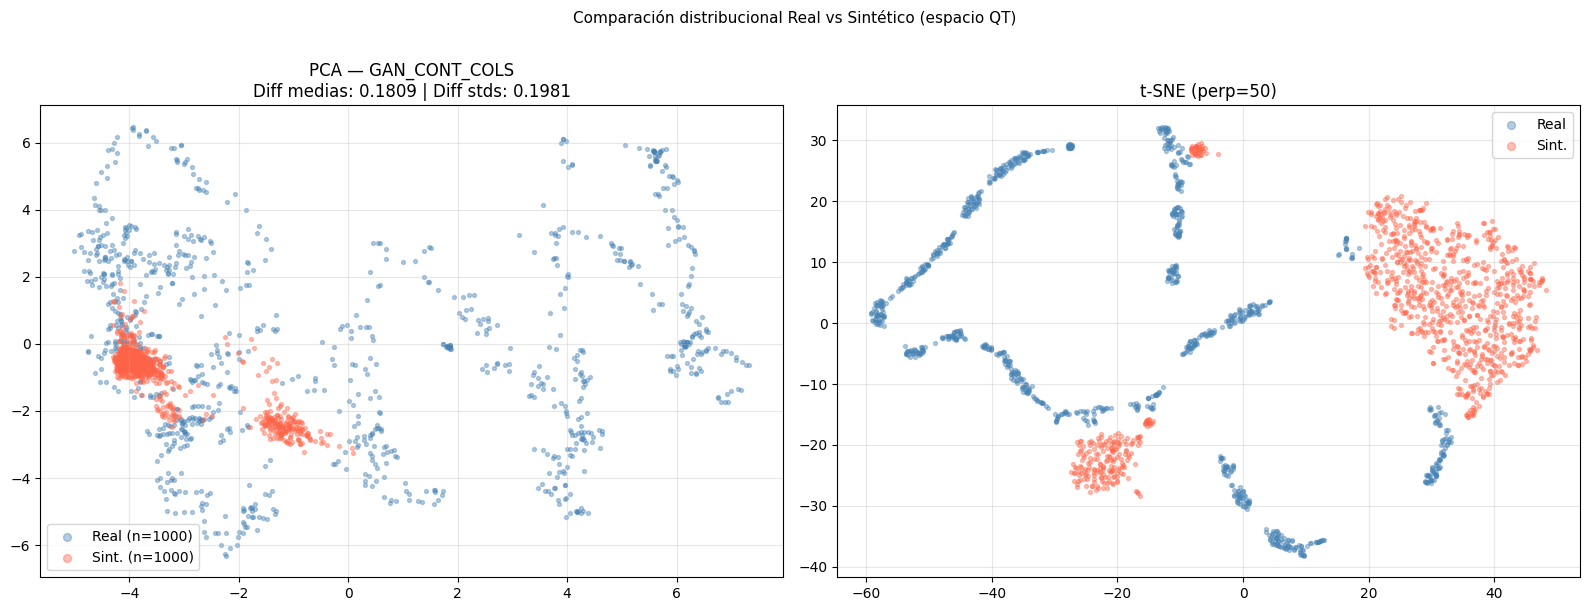

Diff medias: 0.1809  ⚠️
Diff stds:   0.1981  ⚠️


In [25]:
n_plot  = min(1000, len(train_windows), n_synth)
rng     = np.random.default_rng(SEED)
ri      = rng.choice(len(train_windows),  n_plot, replace=False)
si      = rng.choice(n_synth,             n_plot, replace=False)

real_s  = train_windows[ri].reshape(n_plot, -1)
synth_s = synth_qt_clipped[si].reshape(n_plot, -1)

md_diff = np.abs(real_s.mean(0) - synth_s.mean(0)).mean()
sd_diff = np.abs(real_s.std(0)  - synth_s.std(0)).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pca_v = PCA(n_components=2, random_state=SEED)
pr = pca_v.fit_transform(real_s); ps = pca_v.transform(synth_s)
axes[0].scatter(pr[:,0], pr[:,1], alpha=0.4, c="steelblue", s=8, label=f"Real (n={n_plot})")
axes[0].scatter(ps[:,0], ps[:,1], alpha=0.4, c="tomato",    s=8, label=f"Sint. (n={n_plot})")
axes[0].set_title(f"PCA — GAN_CONT_COLS\nDiff medias: {md_diff:.4f} | Diff stds: {sd_diff:.4f}")
axes[0].legend(markerscale=2); axes[0].grid(True, alpha=0.3)

comb = PCA(n_components=min(50, real_s.shape[1]), random_state=SEED).fit_transform(
    np.vstack([real_s, synth_s]))
perp = min(50, n_plot // 5)
tout = TSNE(n_components=2, random_state=SEED, perplexity=perp,
            max_iter=2000, init="pca", learning_rate="auto").fit_transform(comb)
axes[1].scatter(tout[:n_plot,0], tout[:n_plot,1], alpha=0.4, c="steelblue", s=8, label="Real")
axes[1].scatter(tout[n_plot:,0], tout[n_plot:,1], alpha=0.4, c="tomato",    s=8, label="Sint.")
axes[1].set_title(f"t-SNE (perp={perp})"); axes[1].legend(markerscale=2); axes[1].grid(True, alpha=0.3)

plt.suptitle("Comparación distribucional Real vs Sintético (espacio QT)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(str(TIMEGAN_DIR / "tsne_pca.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Diff medias: {md_diff:.4f}  {'✅' if md_diff<0.10 else '⚠️'}")
print(f"Diff stds:   {sd_diff:.4f}  {'✅' if sd_diff<0.10 else '⚠️'}")


In [26]:
X_all = np.vstack([real_s, synth_s])
y_all = np.array([0]*n_plot + [1]*n_plot)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)
clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

fi     = clf.feature_importances_
max_fi = fi.max()
top5   = np.argsort(fi)[-5:][::-1]

print("=" * 55)
print(f"AUC discriminabilidad = {auc:.4f}  (referencial)")
print()
print("NOTA: el AUC del RF con ventanas aplanadas no es la")
print("métrica principal — el TSTR es el resultado definitivo.")
print()
print("Top 5 features más discriminativas:")
for i in top5:
    ci = i // WINDOW_SIZE; ti = i % WINDOW_SIZE
    print(f"  {GAN_CONT_COLS[ci]:25s} t={ti:2d}: {fi[i]:.4f}")
print(f"\nImportancia máxima: {max_fi:.4f}  {'✅' if max_fi<0.05 else '⚠️'}")
print("=" * 55)


AUC discriminabilidad = 1.0000  (referencial)

NOTA: el AUC del RF con ventanas aplanadas no es la
métrica principal — el TSTR es el resultado definitivo.

Top 5 features más discriminativas:
  PIT503.Pv                 t=19: 0.0946
  FIT602.Pv                 t=25: 0.0782
  LIT602.Pv                 t= 7: 0.0436
  LIT601.Pv                 t=13: 0.0413
  LIT401.Pv                 t=26: 0.0412

Importancia máxima: 0.0946  ⚠️


## 15. Guardar artefactos

In [27]:
# Pesos de las 5 redes
for name, model in [("embedder",embedder),("recovery",recovery),("generator",generator),
                    ("supervisor",supervisor),("discriminator",discriminator)]:
    torch.save(model.state_dict(), TIMEGAN_DIR / f"{name}.pt")

# QuantileTransformer del GAN
joblib.dump(qt, ARTIFACTS_DIR / "timegan_quantile_transformer.pkl")

# Catálogos empíricos
with open(TIMEGAN_DIR / "fit_empirical.json", "w") as f:
    json.dump({col: {"p_zero": v["p_zero"], "flow_open_sample": v["flow_open"][:500]}
               for col, v in fit_empirical.items()}, f, indent=2)
with open(TIMEGAN_DIR / "disc_empirical.json", "w") as f:
    json.dump({k: {str(kk): float(vv) for kk,vv in v.items()}
               for k,v in disc_empirical.items()}, f, indent=2)
with open(TIMEGAN_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vs] for k,vs in discrete_value_maps.items()}, f, indent=2)

# Datos sintéticos
np.save(TIMEGAN_DIR / "synth_qt.npy",          synth_qt_clipped)
np.save(TIMEGAN_DIR / "synth_gan_physical.npy", synth_gan_phys)
np.save(TIMEGAN_DIR / "synth_fit_raw.npy",      synth_fit_raw)
np.save(TIMEGAN_DIR / "synth_all_physical.npy", synth_all_phys)
np.save(TIMEGAN_DIR / "synth_for_detector.npy", synth_for_det)
np.save(TIMEGAN_DIR / "synth_disc_raw.npy",     synth_disc_raw)
synth_disc_summary.to_csv(TIMEGAN_DIR / "synth_disc_summary.csv", index=False)

# Config
config = {
    "version":          "a12_timegan_v2",
    "dataset":          "SWaT A12 Mar 2026",
    "csv_path":         str(RAW_CSV),
    "warmup_seconds":   120,
    "n_normal_rows":    len(df_normal),
    "window_size":      WINDOW_SIZE,
    "stride_timegan":   TIMEGAN_STRIDE,
    "gan_cont_cols":    GAN_CONT_COLS,
    "fit_bimodal_cols": FIT_BIMODAL_COLS,
    "empirical_cont_cols": EMPIRICAL_CONT_COLS,
    "discrete_cols":    discrete_cols,
    "continuous_cols":  continuous_cols,
    "feature_cols":     feature_cols,
    "scaler":           "QuantileTransformer(n_quantiles=1000, uniform)",
    "feature_dim":      feature_dim,
    "hidden_dim":       hidden_dim,
    "latent_dim":       latent_dim,
    "num_layers":       num_layers,
    "G_STEPS": G_STEPS, "D_STEPS": D_STEPS, "G_CLIP": G_CLIP, "D_CLIP": D_CLIP,
    "R1_LAMBDA": R1_LAMBDA, "R1_INTERVAL": R1_INTERVAL,
    "gamma": gamma, "eta": eta, "FM_W": FM_W,
    "epochs_embedder": epochs_embedder, "epochs_supervisor": epochs_supervisor,
    "epochs_joint": epochs_joint,
    "v2_changes": ["FIT401+FIT504+P501.Speed→empirical","G_STEPS=3","D_STEPS=1","FM_W=1.0","epochs_embedder=800"], "batch_size": BATCH_SIZE,
    "n_synth_windows": n_synth,
    "metrics": {
        "embedder_mse_final":    float(embedder_history[-1]),
        "supervisor_loss_final": float(supervisor_history[-1]),
        "g_loss_initial":        float(joint_g_history[0]),
        "g_loss_final":          float(joint_g_history[-1]),
        "d_loss_final":          float(joint_d_history[-1]),
        "spikes_g35":            int(sum(1 for g in joint_g_history if g > 3.5)),
        "diff_medias_qt":        float(md_diff),
        "diff_stds_qt":          float(sd_diff),
        "auc_rf":                float(auc),
        "rf_importancia_max":    float(max_fi),
    }
}
with open(TIMEGAN_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=4)

pd.DataFrame({
    "epoch": range(1, len(joint_g_history)+1),
    "g_loss": joint_g_history,
    "d_loss": joint_d_history,
    "e_loss": joint_e_history,
}).to_csv(TIMEGAN_DIR / "training_history.csv", index=False)

print("✅ Artefactos guardados en:", TIMEGAN_DIR.resolve())
print()
for fp in sorted(TIMEGAN_DIR.iterdir()):
    sz = fp.stat().st_size
    unit = "KB" if sz < 1e6 else "MB"
    print(f"  {fp.name:<40} {sz/1e3 if sz<1e6 else sz/1e6:6.1f} {unit}")


✅ Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_a12_v2

  config.json                                 5.2 KB
  disc_empirical.json                         3.1 KB
  discrete_value_maps.json                    1.6 KB
  discriminator.pt                            1.2 MB
  embedder.pt                                 1.1 MB
  fit_empirical.json                         50.6 KB
  generator.pt                                1.2 MB
  recovery.pt                                 1.2 MB
  supervisor.pt                             861.5 KB
  synth_all_physical.npy                     11.4 MB
  synth_disc_raw.npy                         11.4 MB
  synth_disc_summary.csv                      1.3 MB
  synth_fit_raw.npy                           2.2 MB
  synth_for_detector.npy                     11.4 MB
  synth_gan_physical.npy                      8.8 MB
  synth_qt.npy                            